# 04 - Hyperparameter Tuning
**Goal**: Find the best LightGBM hyperparameters using time-series cross-validation.

We use **TimeSeriesSplit** (not random CV) so we never train on future data to predict the past.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
%matplotlib inline

HORIZON = 24

## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/processed/demand_with_weather.csv', index_col='timestamp', parse_dates=True)
df = df.dropna(subset=['heat_demand_mw'])

df['demand_lag_25h']   = df['heat_demand_mw'].shift(HORIZON + 1)
df['demand_lag_48h']   = df['heat_demand_mw'].shift(48)
df['demand_lag_168h']  = df['heat_demand_mw'].shift(168)
df['demand_lag_336h']  = df['heat_demand_mw'].shift(336)
df['demand_roll_48h']  = df['heat_demand_mw'].shift(HORIZON + 1).rolling(48).mean()
df['demand_roll_168h'] = df['heat_demand_mw'].shift(HORIZON + 1).rolling(168).mean()
df = df.dropna()

FEATURES = [
    'temperature_c', 'heating_degrees', 'temp_change_3h',
    'wind_speed_ms', 'wind_sin', 'wind_cos',
    'solar_radiation_wm2', 'humidity_pct',
    'snowfall_cm', 'snow_depth_m', 'cloud_cover_pct',
    'hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend',
    'is_holiday', 'is_school_holiday', 'heating_season_day',
    'demand_lag_25h', 'demand_lag_48h', 'demand_lag_168h', 'demand_lag_336h',
    'demand_roll_48h', 'demand_roll_168h'
]
TARGET = 'heat_demand_mw'

# Use only training years for tuning (hold out 2024 as final test)
train_df = df[df.index.year < 2024]
X_all = train_df[FEATURES]
y_all = train_df[TARGET]

print(f'Tuning data: {len(train_df)} rows')

Tuning data: 34724 rows


## 2. Define Parameter Grid

In [3]:
# Parameter combinations to try
param_grid = [
    {'num_leaves': 31,  'learning_rate': 0.05, 'min_data_in_leaf': 20, 'n_estimators': 500},
    {'num_leaves': 63,  'learning_rate': 0.05, 'min_data_in_leaf': 20, 'n_estimators': 500},
    {'num_leaves': 127, 'learning_rate': 0.05, 'min_data_in_leaf': 20, 'n_estimators': 500},
    {'num_leaves': 63,  'learning_rate': 0.02, 'min_data_in_leaf': 20, 'n_estimators': 1000},
    {'num_leaves': 63,  'learning_rate': 0.1,  'min_data_in_leaf': 20, 'n_estimators': 300},
    {'num_leaves': 63,  'learning_rate': 0.05, 'min_data_in_leaf': 50, 'n_estimators': 500},
    {'num_leaves': 127, 'learning_rate': 0.02, 'min_data_in_leaf': 30, 'n_estimators': 1000},
    {'num_leaves': 255, 'learning_rate': 0.02, 'min_data_in_leaf': 50, 'n_estimators': 1000},
]
print(f'Testing {len(param_grid)} parameter combinations with time-series CV')

Testing 8 parameter combinations with time-series CV


## 3. Time-Series Cross-Validation
5 folds, each fold trains on past data and tests on the next block — no future leakage.

In [4]:
tscv = TimeSeriesSplit(n_splits=5)

def cv_score(params):
    maes = []
    for train_idx, val_idx in tscv.split(X_all):
        X_tr, y_tr = X_all.iloc[train_idx], y_all.iloc[train_idx]
        X_val, y_val = X_all.iloc[val_idx], y_all.iloc[val_idx]
        model = lgb.LGBMRegressor(**params, n_jobs=-1, random_state=42)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        maes.append(mean_absolute_error(y_val, preds))
    return np.mean(maes)

results = []
for i, params in enumerate(param_grid):
    score = cv_score(params)
    results.append({**params, 'cv_mae': round(score, 3)})
    print(f'[{i+1}/{len(param_grid)}] leaves={params["num_leaves"]:3d} lr={params["learning_rate"]} '
          f'min_leaf={params["min_data_in_leaf"]} n_est={params["n_estimators"]:4d}  ->  CV MAE: {score:.3f}')

results_df = pd.DataFrame(results).sort_values('cv_mae')
print('\n--- Results ranked by CV MAE ---')
print(results_df.to_string(index=False))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3903
[LightGBM] [Info] Number of data points in the train set: 5789, number of used features: 25
[LightGBM] [Info] Start training from score 115.192230
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min

## 4. Train Best Model on Full Training Set, Evaluate on 2024

In [5]:
best_params = results_df.iloc[0].drop('cv_mae').to_dict()
best_params = {k: int(v) if k != 'learning_rate' else v for k, v in best_params.items()}
print('Best params:', best_params)

test_df = df[df.index.year == 2024]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

best_model = lgb.LGBMRegressor(**best_params, n_jobs=-1, random_state=42)
best_model.fit(X_all, y_all)
best_preds = pd.Series(best_model.predict(X_test), index=y_test.index)

mae  = mean_absolute_error(y_test, best_preds)
rmse = np.sqrt(mean_squared_error(y_test, best_preds))
mape = np.mean(np.abs((y_test - best_preds) / y_test.clip(lower=1))) * 100
print(f'\nBest Model (2024 test set):')
print(f'  MAE:  {mae:.2f} MW')
print(f'  RMSE: {rmse:.2f} MW')
print(f'  MAPE: {mape:.1f}%')

Best params: {'num_leaves': 31, 'learning_rate': 0.05, 'min_data_in_leaf': 20, 'n_estimators': 500}
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4051
[LightGBM] [Info] Number of data points in the train set: 34724, number of used features: 25
[LightGBM] [Info] Start training from score 128.634756
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

Best Model (2024 test set):
  MAE:  8.62 MW
  RMSE: 12.67 MW
  MAPE: 7.8%


## 5. Predicted vs Actual — Winter Week (Jan 2024)

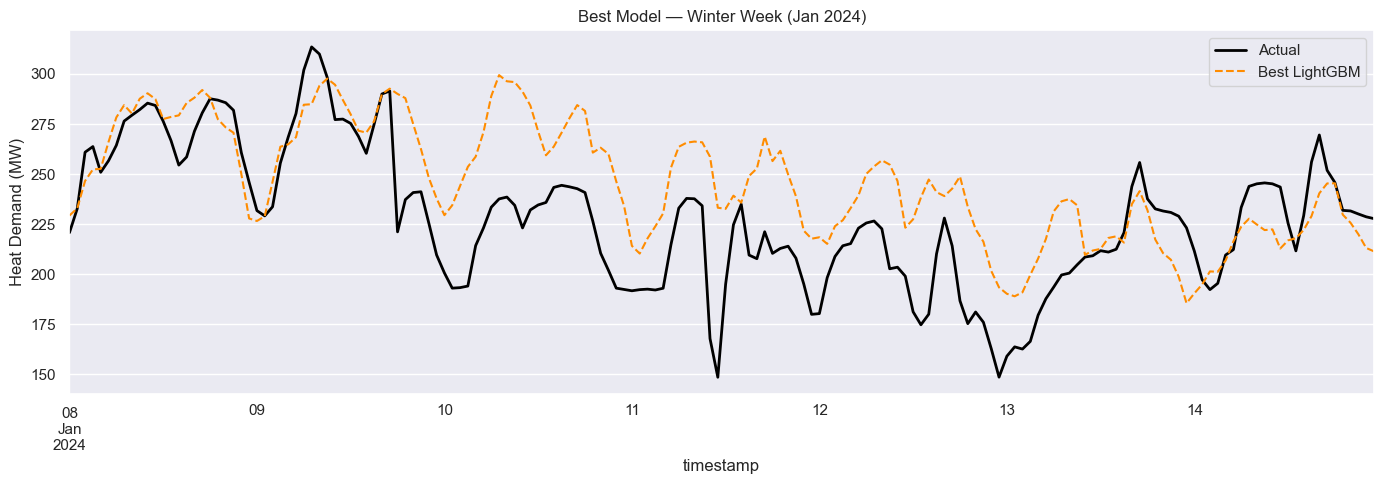

In [6]:
def plot_week(start, title):
    mask = (y_test.index >= start) & (y_test.index < pd.Timestamp(start) + pd.Timedelta(days=7))
    fig, ax = plt.subplots(figsize=(14, 5))
    y_test[mask].plot(ax=ax, label='Actual', linewidth=2, color='black')
    best_preds[mask].plot(ax=ax, label='Best LightGBM', linestyle='--', color='darkorange')
    ax.set_title(title)
    ax.set_ylabel('Heat Demand (MW)')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_week('2024-01-08', 'Best Model — Winter Week (Jan 2024)')

## 6. Predicted vs Actual — Autumn Week (Oct 2024)

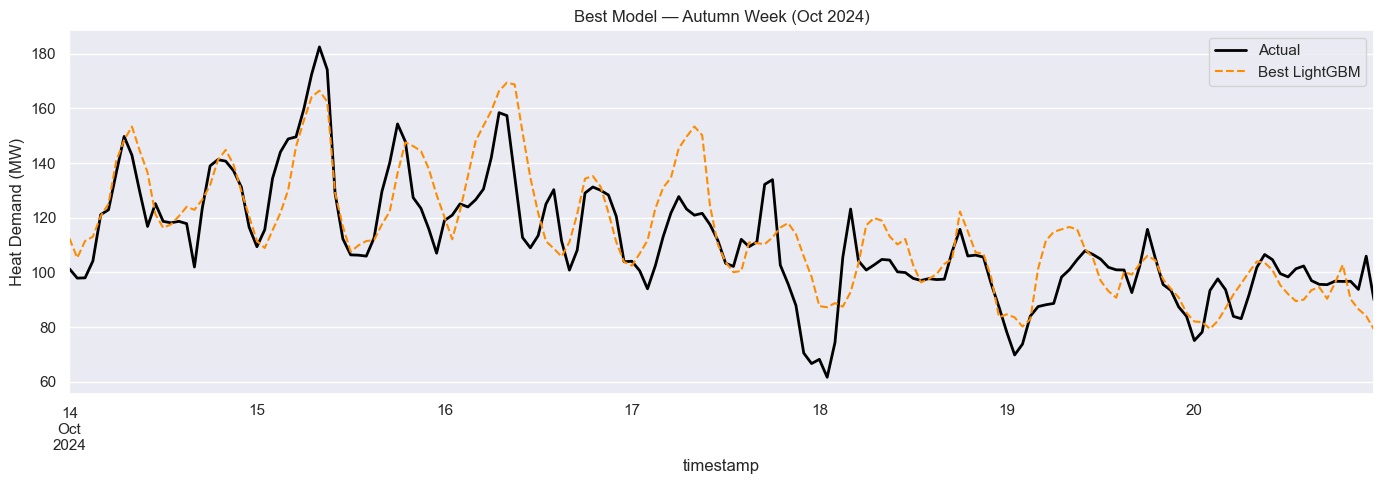

In [7]:
plot_week('2024-10-14', 'Best Model — Autumn Week (Oct 2024)')

## 7. Error Analysis by Month

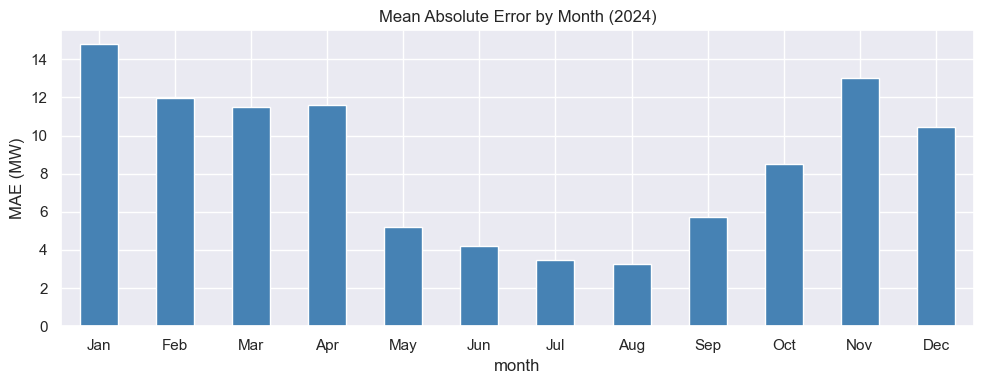

In [8]:
errors = pd.DataFrame({'actual': y_test, 'predicted': best_preds})
errors['abs_error'] = (errors['actual'] - errors['predicted']).abs()
errors['month'] = errors.index.month

monthly_error = errors.groupby('month')['abs_error'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
monthly_error.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xticklabels([month_labels[i-1] for i in monthly_error.index], rotation=0)
ax.set_title('Mean Absolute Error by Month (2024)')
ax.set_ylabel('MAE (MW)')
plt.tight_layout()
plt.show()

## 8. Feature Importance

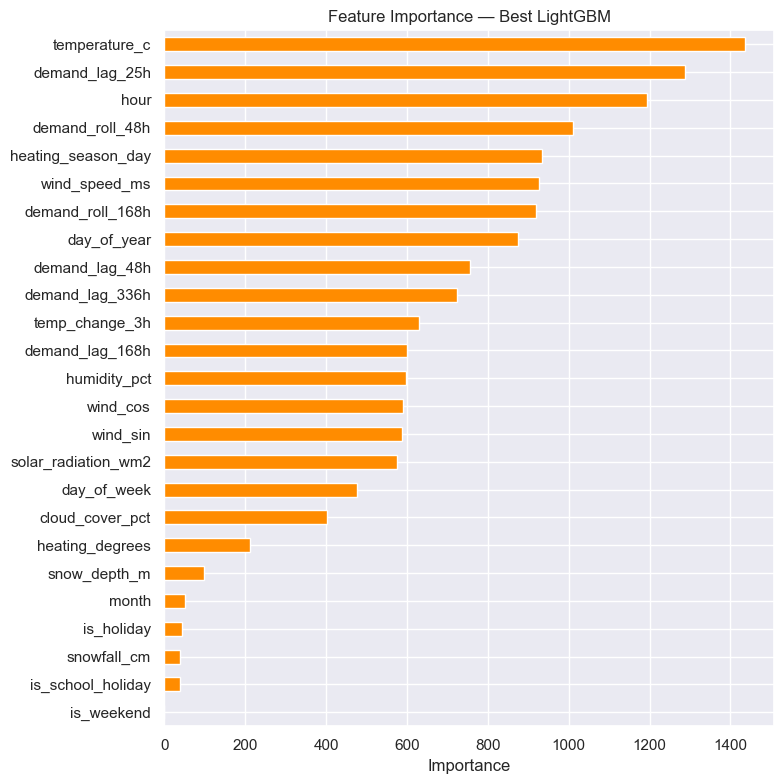

In [9]:
importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importance.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Feature Importance — Best LightGBM')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()